In [1]:
## This Notebook contains the plots and diagrams for the single exponential fit function

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from multiprocessing import Pool
from sklearn.linear_model import LinearRegression
import matplotlib.patches as mpatches



In [3]:
def boot_error_helper(data):
        E_list = []
        x = data["x"]
        y = data["y"]
        log_y = np.log(y)
        for i in range(100):
            idx = np.random.choice(a = np.arange(0,x.shape[0]),size = x.shape[0])
        
            x_boot = x[idx]
            log_y_boot = log_y[idx]
            reg = LinearRegression(fit_intercept=True,n_jobs=1).fit(x_boot.reshape(-1, 1), log_y_boot)
            ### To a linear fit --->
            E_list.append(-1*reg.coef_[0])
            
        return np.array(E_list)

def single_exponential_fit_with_error(x,y,Nproc = 64,Nprocess = 100):
    
    
    Nproc = 100
    Nprocess = 100
    pool = Pool(Nproc)
    results = np.concatenate(pool.map(boot_error_helper,[{"x":x,"y":y}]*Nprocess))

    return np.mean(results), np.std(results,ddof=1)

In [4]:
DATA_PATH = "../../../CorrelatorStudy/Bdata/ext2/"

In [5]:
signal_list  = [
    "B0_st",
    "cas_q_hl_32",
    "cas_c_hh_12",
    "lambcs_bc_32"]

In [6]:

plot_data = {}

for signal in signal_list:
    f = open(f"{DATA_PATH}/{signal}", "r")
    data = f.readlines()
    f.close()
    
    
    plot_x = []
    E0_spec = []
    E0_uncertainty = []
    mean_e0_bootstrap = []
    std_e0_bootstrap = []
    for i in tqdm(range(0,23)):
        CUT = i
        ################################################################################################
        y = np.array(list(map(lambda x: abs(float(x.split("\t")[-1].split("\n")[0])), data)), dtype=float)
        x = np.array(list(map(lambda x: float(x.split("\t")[0].split("\n")[0]), data)), dtype=float)
        
        idx = (x>=CUT)
        
        x = x[idx]
        y = y[idx]
        
        plot_x.append(i)
        
        mean_e0_bootstrap_,std_e0_bootstrap_ = single_exponential_fit_with_error(x,y)
        mean_e0_bootstrap.append(mean_e0_bootstrap_)
        std_e0_bootstrap.append(std_e0_bootstrap_)
        
    mean_e0_bootstrap = np.array(mean_e0_bootstrap)
    std_e0_bootstrap = np.array(std_e0_bootstrap)

    plot_data[signal] = {"mean":mean_e0_bootstrap,
                         "std":std_e0_bootstrap}


  0%|          | 0/23 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

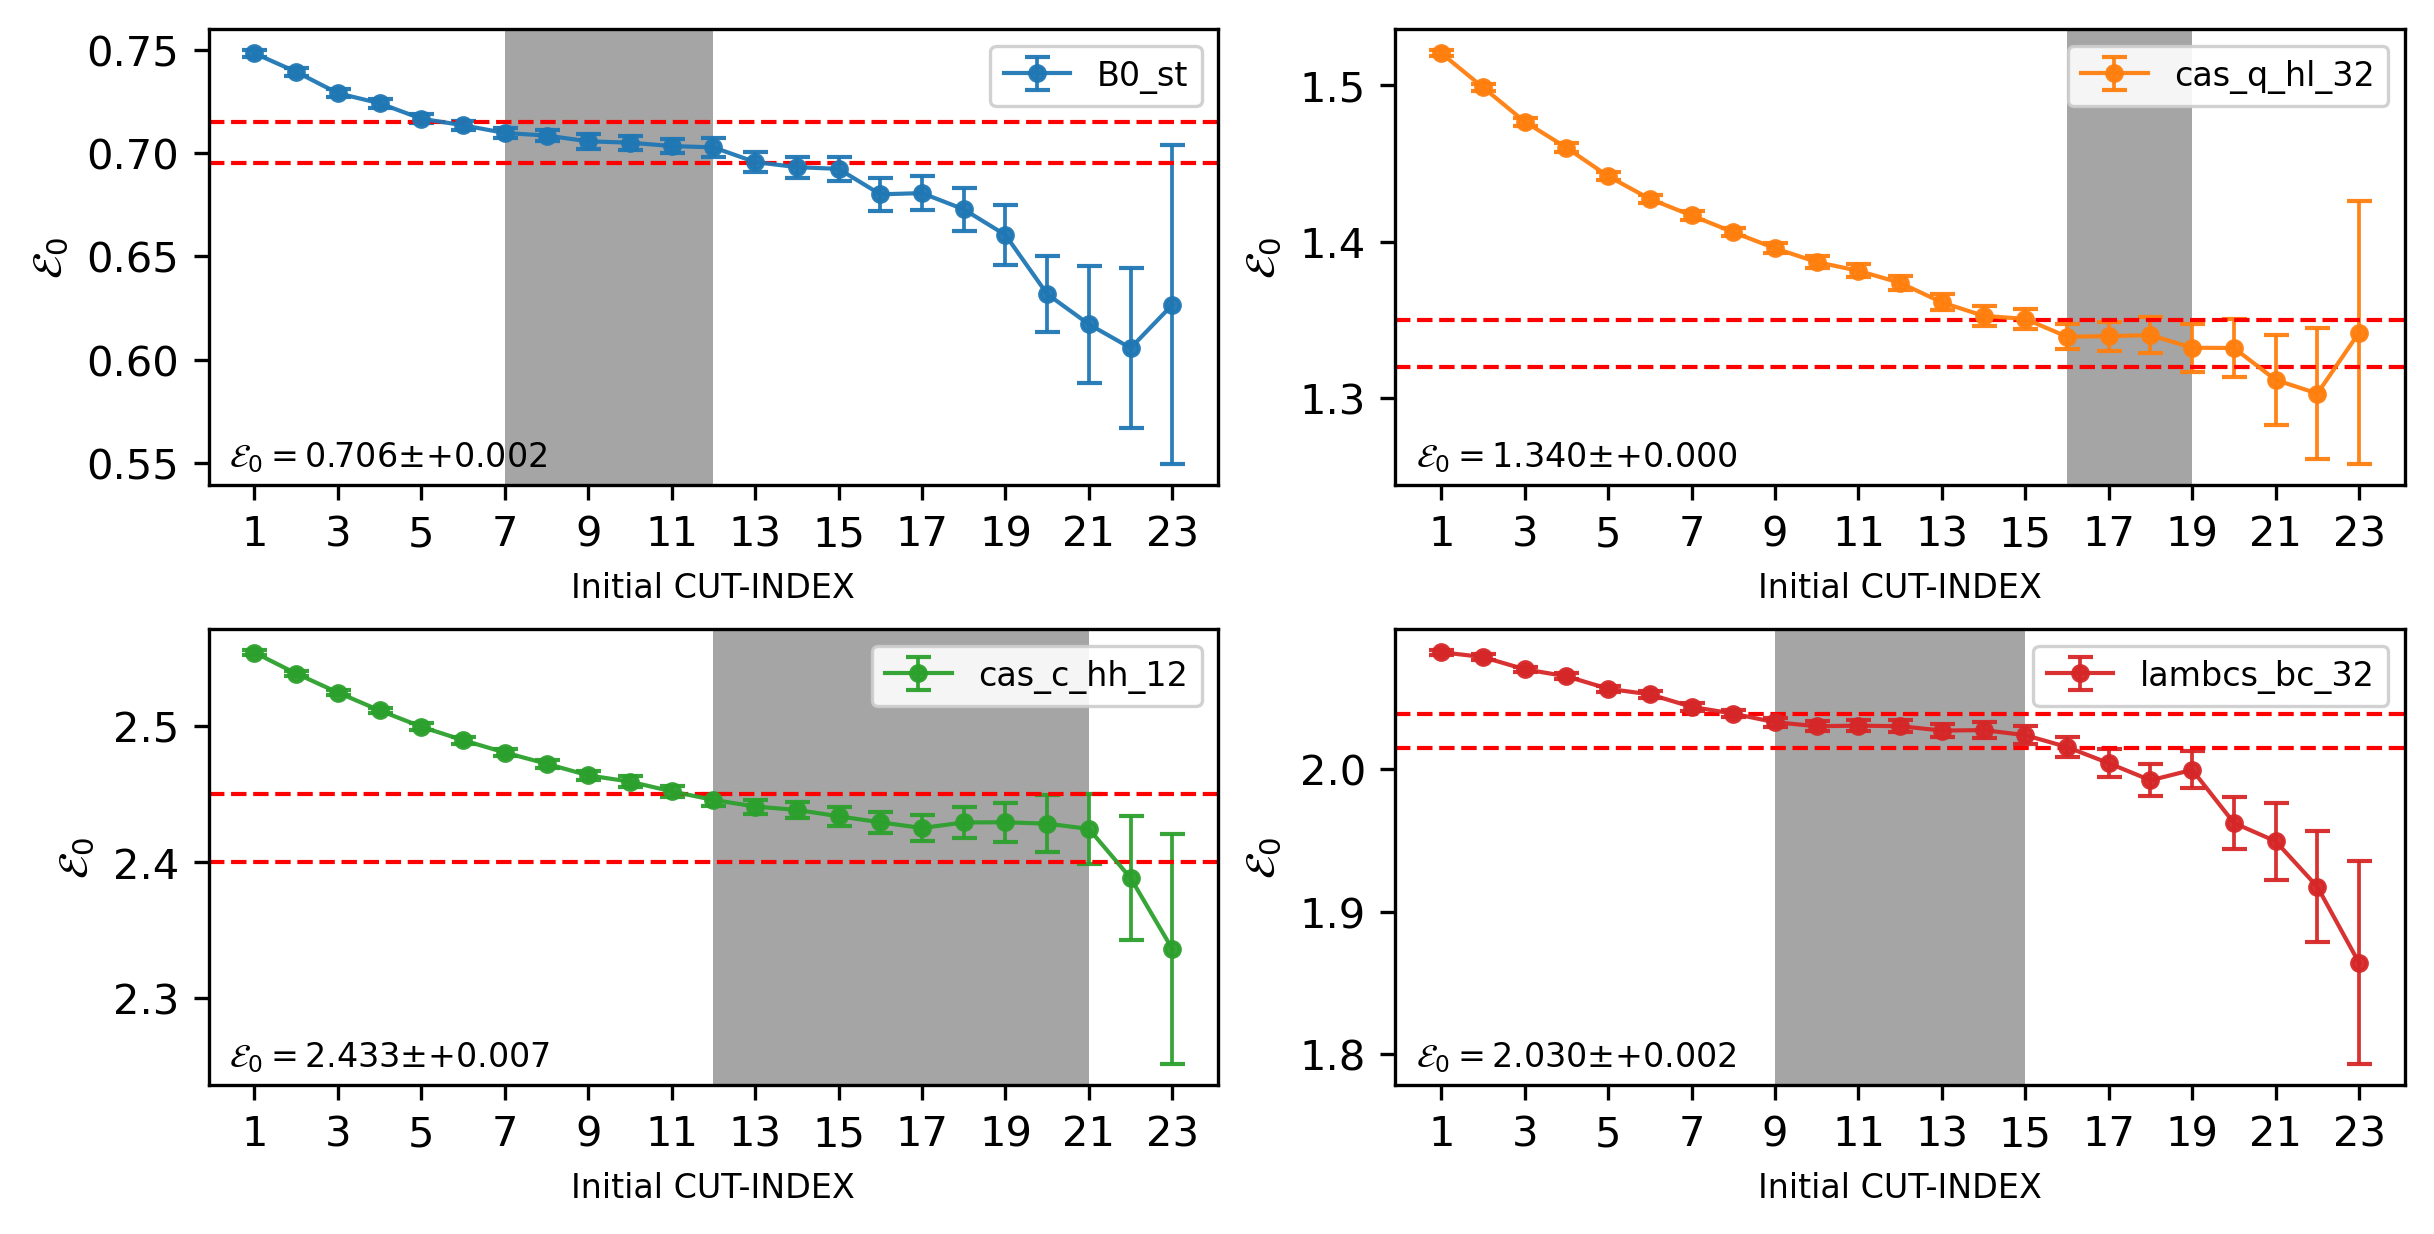

In [9]:
signals = list(plot_data.keys())
n_panels = 4

groups = [signals[i::n_panels] for i in range(n_panels)]

fig, axes = plt.subplots(2, 2, figsize=(8, 4), dpi=300, constrained_layout=True)
axes = axes.ravel()

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]


bands = {
    0: [6, 11],
    1: [15, 18],          
    2: [11, 20], 
    3: [8, 14] 
}

energy = {
    0:[0.695,0.715],
    1:[1.35,1.32],
    2:[2.4,2.45],
    3:[2.015,2.039],
}



for ax_idx, ax in enumerate(axes):
    handles = []
    for signal in groups[ax_idx]:
        y_mean = np.asarray(plot_data[signal]["mean"])
        y_std  = np.asarray(plot_data[signal]["std"])

        h = ax.errorbar(plot_x, y_mean, yerr=y_std,
            fmt="o-", capsize=3, linewidth=1.0, elinewidth=0.9,
            markersize=3.5, alpha=0.95, label=signal,color = colors[ax_idx])
        handles.append(h)

        ax.axhline(y=energy[ax_idx][0], color='r', linestyle='--', linewidth=1)
        ax.axhline(y=energy[ax_idx][1], color='r', linestyle='--', linewidth=1)
        ax.text(0.02, 0.1, (r"$\mathcal{E}_0=$"+f"{np.array(y_mean[bands[ax_idx][0]:bands[ax_idx][1]]).mean():.3f}"+r"$\pm$+"f"{np.std(y_mean[bands[ax_idx][0]:bands[ax_idx][1]]).mean():.3f}"), transform=ax.transAxes,ha="left", va="top", fontsize=8)
                                



    ax.set_xticks(plot_x[::2])
    ax.set_xticklabels((np.array(plot_x)[::2] + 1).tolist())

    ax.set_xlabel("Initial CUT-INDEX", fontsize=8)
    ax.set_ylabel(r"$\mathcal{E}_0$", fontsize=10)

    
    (x0, x1) = bands[ax_idx]
    ax.axvspan(x0, x1, facecolor="0.3", alpha=0.5, zorder=0)

    if handles:
        leg = ax.legend(loc="upper right", frameon=True, ncol=1,fontsize=8)
        leg.get_frame().set_alpha(0.9)
        leg.get_frame().set_linewidth(0.8)
plt.savefig("../assets/fig1.png")
plt.show()
